# 04 Why did emissions change? The Kaya decomposition

Notebook 03 showed *which* countries decoupled. This one asks *why*. When a country's emissions fall, it could be for very different reasons: fewer people, a weaker economy, using energy more efficiently, or switching to cleaner fuels. Only the last two are what we'd call a real energy transition, so it matters which one is doing the work.

## The idea

The **Kaya identity** breaks emissions into four factors that multiply together:

$$\text{CO}_2 = \underbrace{P}_{\text{population}} \times \underbrace{\frac{GDP}{P}}_{\text{affluence}} \times \underbrace{\frac{E}{GDP}}_{\text{energy intensity}} \times \underbrace{\frac{\text{CO}_2}{E}}_{\text{carbon intensity}}$$

| Factor | What it measures | If it falls... |
|---|---|---|
| Population | Number of people | Fewer people, fewer emissions |
| Affluence | GDP per person | People are poorer on average |
| Energy intensity | Energy used per unit of GDP | The economy does more with less energy (efficiency, or a shift from heavy industry to services) |
| Carbon intensity | CO2 per unit of energy | The energy itself is cleaner (less coal, more renewables or nuclear) |

It's an identity, so it's always true: the fractions cancel out and leave CO2 = CO2. The useful part is what comes next.

## The method: LMDI

The **Logarithmic Mean Divisia Index** (LMDI) takes the change in emissions between two points in time and splits it into how many tonnes each factor contributed. I use it because the four effects add up *exactly* to the real change, with no unexplained leftover. Simpler methods leave a residual that has to be fudged. It's the standard method in the energy literature (Ang, 2005).

The code lives in `src/kaya.py`. Everything here uses the same 143-country sample and the same three-year averaged start and end points as notebook 03.

In [1]:
# --- Setup ---
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "requirements.txt").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from src.config import DATA_PROCESSED, FIGURES, TABLES, START_YEAR, END_YEAR, AVG_WINDOW
from src.sample import classify_period
from src.kaya import kaya_factors, lmdi, FACTORS
from src.plotting import set_style, KAYA_COLOURS, GREY, INK_SOFT

set_style()
pd.set_option("display.width", 120)

sample = (pd.read_parquet(DATA_PROCESSED / "analysis_panel.parquet")
          .rename(columns={"primary_energy_consumption": "energy"}))
KAYA_COLS = ["population", "gdp", "energy", "co2"]

def endpoints(df, start, end, window=AVG_WINDOW):
    """Averaged start and end values of the four Kaya inputs, one row per country."""
    first = df[df["year"].between(start, start + window - 1)].groupby("country")[KAYA_COLS].mean()
    last = df[df["year"].between(end - window + 1, end)].groupby("country")[KAYA_COLS].mean()
    return first, last

print(f"Sample: {sample['country'].nunique()} countries")

Sample: 143 countries


## 1. Check the identity holds

Before trusting the decomposition, a quick test: multiply the four factors back together and compare with actual emissions. They should match perfectly for every country and year.

In [2]:
factors = kaya_factors(sample["population"], sample["gdp"], sample["energy"], sample["co2"])
rebuilt = factors.prod(axis=1)
gap = (rebuilt - sample["co2"]).abs().max()
print(f"Largest gap between rebuilt and actual CO2: {gap:.2e} million tonnes")

Largest gap between rebuilt and actual CO2: 2.73e-12 million tonnes


The gap is effectively zero (tiny differences like this are just how computers store decimals).

## 2. Run the decomposition, 1990 to 2022

In [3]:
start, end = endpoints(sample, START_YEAR, END_YEAR)
effects = lmdi(start, end)

# Check the four effects add up to the real change
residual = (effects[FACTORS].sum(axis=1) - effects["Total change"]).abs().max()
print(f"Largest leftover after adding up the four effects: {residual:.2e} Mt")

# Also express each effect as a % of the country's starting emissions,
# so a small country and a large one can be compared on the same scale
effects_pct = effects.div(start["co2"], axis=0) * 100
effects.round(0).head()

Largest leftover after adding up the four effects: 3.41e-12 Mt


,Population,Affluence,Energy intensity,Carbon intensity,Total change
country,,,,,
Afghanistan,6.0,2.0,-3.0,4.0,9.0
Albania,-1.0,6.0,-5.0,0.0,1.0
Algeria,67.0,124.0,-93.0,7.0,104.0
Angola,11.0,16.0,-13.0,-0.0,14.0
Argentina,45.0,65.0,-27.0,-20.0,62.0


A leftover of essentially zero confirms the decomposition is exact.

### How to read the numbers

Each number is how much that factor alone pushed emissions up (positive) or down (negative). Take a country with +26% from affluence: if nothing else had changed, richer people alone would have raised its emissions by about a quarter.

## 3. The UK, step by step

A waterfall chart shows the decomposition as a journey from starting emissions to ending emissions, one factor at a time.

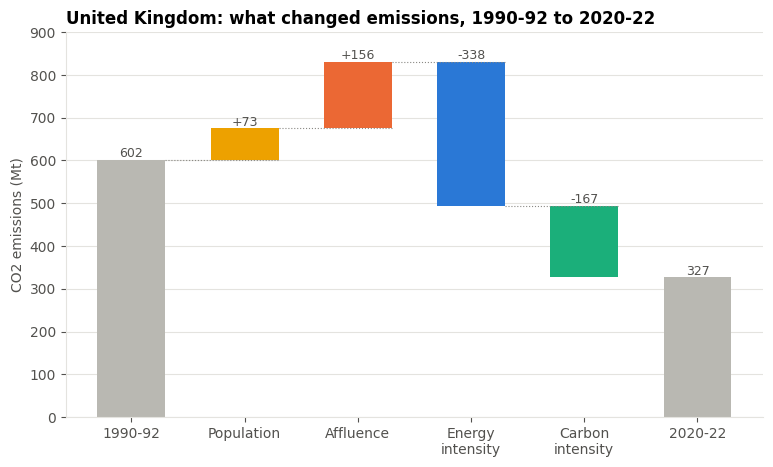

Population          12.0
Affluence           26.0
Energy intensity   -56.0
Carbon intensity   -28.0
Total change       -46.0
Name: United Kingdom, dtype: float64

In [4]:
def waterfall(ax, start_value, parts, end_value, title, unit="Mt"):
    """Draw a waterfall: start bar, one floating bar per factor, end bar."""
    labels = [f"{START_YEAR}-{str(START_YEAR + AVG_WINDOW - 1)[2:]}"] + [n.replace(" ", "\n") for n in parts.index] + [f"{END_YEAR - AVG_WINDOW + 1}-{str(END_YEAR)[2:]}"]
    running = start_value
    ax.bar(0, start_value, color="#b9b8b2", width=0.6)
    ax.text(0, start_value, f"{start_value:,.0f}", ha="center", va="bottom", fontsize=9, color=INK_SOFT)
    for i, (name, value) in enumerate(parts.items(), start=1):
        bottom = running if value >= 0 else running + value
        ax.bar(i, abs(value), bottom=bottom, color=KAYA_COLOURS[name], width=0.6)
        ax.text(i, running + max(value, 0) , f"{value:+,.0f}", ha="center", va="bottom", fontsize=9, color=INK_SOFT)
        ax.plot([i - 0.7, i + 0.3], [running, running], color=GREY, linewidth=0.8, linestyle=":")
        running += value
    ax.plot([len(parts) - 0.7 + 1, len(parts) + 0.3], [running, running], color=GREY, linewidth=0.8, linestyle=":")
    ax.bar(len(parts) + 1, end_value, color="#b9b8b2", width=0.6)
    ax.text(len(parts) + 1, end_value, f"{end_value:,.0f}", ha="center", va="bottom", fontsize=9, color=INK_SOFT)
    ax.set_xticks(range(len(labels)), labels)
    ax.grid(axis="x", visible=False)
    ax.set_ylabel(f"CO2 emissions ({unit})")
    ax.set_title(title)

uk = "United Kingdom"
fig, ax = plt.subplots(figsize=(9, 5))
waterfall(ax, start.loc[uk, "co2"], effects.loc[uk, FACTORS], end.loc[uk, "co2"],
          "United Kingdom: what changed emissions, 1990-92 to 2020-22")
ax.set_ylim(0, 900)
fig.savefig(FIGURES / "04_uk_waterfall.png")
plt.show()

effects_pct.loc[uk].round(0)

Reading left to right: the UK started at around 600 Mt. Population growth and rising incomes on their own would have pushed emissions up by about 230 Mt. But the economy became far less energy-hungry, which took off about 330 Mt, and the energy it did use became cleaner, which took off another 170 Mt.

So the UK's cut came from **both** transition levers, with energy intensity doing roughly twice as much as cleaner energy. A big part of that energy intensity fall is the long shift from manufacturing to services, which leads straight into the question notebook 05 will test: did some of that heavy industry simply move abroad?

## 4. Comparing countries

Now the same decomposition for a set of countries, shown as a percentage of each country's starting emissions. Bars to the right pushed emissions up; bars to the left pulled them down. The black dot is the actual net change.

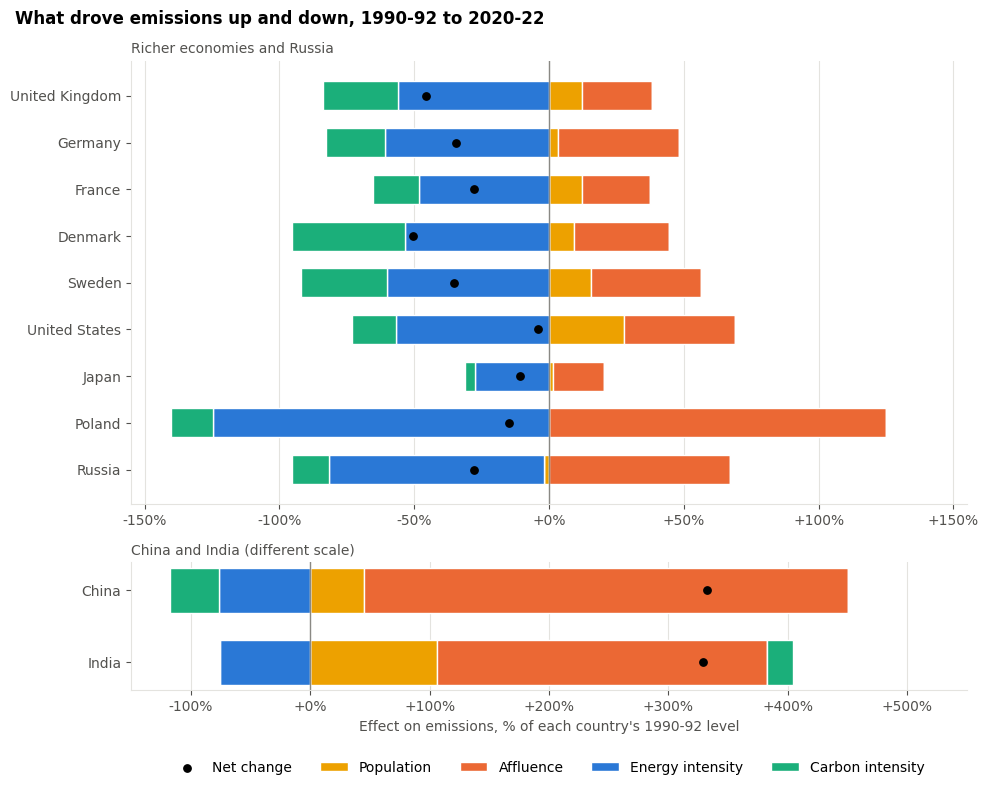

,Population,Affluence,Energy intensity,Carbon intensity,Total change
country,,,,,
United Kingdom,12.0,26.0,-56.0,-28.0,-46.0
Germany,3.0,45.0,-61.0,-22.0,-34.0
France,12.0,25.0,-48.0,-17.0,-28.0
Denmark,9.0,35.0,-53.0,-42.0,-51.0
Sweden,15.0,41.0,-60.0,-32.0,-35.0
United States,28.0,41.0,-57.0,-16.0,-4.0
Japan,1.0,19.0,-27.0,-4.0,-11.0
Poland,0.0,125.0,-125.0,-16.0,-15.0
Russia,-2.0,67.0,-80.0,-14.0,-28.0


In [5]:
# Two panels on normal (linear) scales, so stacked bars add up honestly.
# China and India get their own panel because their growth effects are
# several times larger than everyone else's.
groups = {
    "Richer economies and Russia": ["United Kingdom", "Germany", "France", "Denmark", "Sweden",
                                    "United States", "Japan", "Poland", "Russia"],
    "China and India (different scale)": ["China", "India"],
}

def kaya_bars(ax, view):
    y = np.arange(len(view))
    pos = np.zeros(len(view))
    neg = np.zeros(len(view))
    for f in FACTORS:
        v = view[f].values
        up, down = np.where(v > 0, v, 0), np.where(v < 0, v, 0)
        ax.barh(y, up, left=pos, color=KAYA_COLOURS[f], height=0.62, label=f, edgecolor="white", linewidth=1)
        ax.barh(y, down, left=neg, color=KAYA_COLOURS[f], height=0.62, edgecolor="white", linewidth=1)
        pos += up
        neg += down
    ax.scatter(view["Total change"], y, color="black", s=28, zorder=5, label="Net change")
    ax.axvline(0, color=GREY, linewidth=1)
    ax.set_yticks(y, view.index)
    ax.grid(axis="y", visible=False)
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:+.0f}%"))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [9, 2.6]})
for ax, (title, names) in zip(axes, groups.items()):
    kaya_bars(ax, effects_pct.loc[names[::-1]])
    ax.set_title(title, fontsize=10, color=INK_SOFT, fontweight="normal")
axes[0].set_xlim(-155, 155)
axes[1].set_xlim(-150, 550)
axes[1].set_xlabel("Effect on emissions, % of each country's 1990-92 level")
fig.suptitle("What drove emissions up and down, 1990-92 to 2020-22", x=0.02, ha="left", fontweight="bold", fontsize=12)
axes[1].legend(ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.45))
fig.tight_layout()
fig.savefig(FIGURES / "04_kaya_by_country.png")
plt.show()

effects_pct.loc[sum(groups.values(), [])].round(0)

A few things stand out:

- **Energy intensity is the biggest brake nearly everywhere.** In most of these countries it cut emissions by roughly 50% to 80% of their starting level (Japan, already efficient in 1990, is the exception). Even in China and India, huge efficiency gains held back what would otherwise have been far larger increases.
- **Rich countries used both levers.** The UK, Germany, Denmark and Sweden all cut carbon intensity by 20% or more. Denmark stands out, with cleaner energy (-42%) almost matching its efficiency gains, which fits its move to wind seen in notebook 03.
- **China's story is growth, not failure.** Rising incomes alone would have multiplied its emissions about five times over. Efficiency and cleaner energy cut a lot, but nowhere near enough to offset growth on that scale.
- **India's energy got dirtier.** Its carbon intensity *rose* by about 21%, as coal expanded to meet demand. It's one of the clearest cases where the energy mix moved the wrong way.
- **Poland's cut came almost entirely from efficiency.** Despite the big fall in coal's share seen in notebook 03, its carbon intensity only fell 16%, because coal was largely replaced by oil and gas rather than clean sources.
- **Russia's efficiency gains partly reflect the post-Soviet collapse** of heavy industry, as flagged in notebook 03.

## 5. Which lever did the absolute decouplers pull?

For the 34 countries that grew their economies while cutting emissions, which reduction was bigger: using less energy per unit of GDP, or using cleaner energy?

In [6]:
labels = classify_period(sample, START_YEAR, END_YEAR)["decoupling"]
absolute = effects_pct[labels == "Absolute"]

bigger = np.where(absolute["Energy intensity"] < absolute["Carbon intensity"], "Energy intensity", "Carbon intensity")
absolute = absolute.assign(bigger_lever=bigger)

print(absolute["bigger_lever"].value_counts().to_string(), "\n")
print("Countries where cleaner energy did more than efficiency:")
print(", ".join(sorted(absolute.index[absolute["bigger_lever"] == "Carbon intensity"])))

bigger_lever
Energy intensity    30
Carbon intensity     4 

Countries where cleaner energy did more than efficiency:
Greece, Kuwait, Portugal, Spain


Energy intensity was the bigger lever in 30 of the 34 absolute decouplers. Only a handful cut emissions mainly by cleaning up their energy. Spain and Portugal fit the renewables story, since both grew wind and solar strongly. Greece's result is partly the recession effect from notebook 03, and Kuwait's reflects the 1991 oil fires at its starting point.

This is one of the more useful findings in the project. The popular story of decarbonisation is about wind farms and solar panels, but over this period, doing more with less energy did most of the work. Cleaner energy is growing in importance, though, as the next section shows.

## 6. Where did energy get dirtier?

Carbon intensity doesn't always fall. Where countries have added coal faster than clean sources, their energy has become more carbon-heavy.

In [7]:
dirtier = effects_pct[effects_pct["Carbon intensity"] > 0]
print(f"Carbon intensity rose in {len(dirtier)} of {len(effects_pct)} countries.\n")

# The largest ones in absolute terms
effects.loc[dirtier.index].sort_values("Carbon intensity", ascending=False).head(8)[["Carbon intensity", "Total change"]].round(0)

Carbon intensity rose in 56 of 143 countries.



,Carbon intensity,Total change
country,,
India,132.0,2027.0
Egypt,35.0,179.0
Kazakhstan,33.0,13.0
Iraq,24.0,143.0
Indonesia,22.0,495.0
Nigeria,21.0,92.0
South Africa,10.0,121.0
Philippines,10.0,97.0


Carbon intensity rose in more than a third of the sample. In absolute tonnes, India dominates, followed by countries like Egypt, Kazakhstan, Iraq and Indonesia. Most of these are fast-growing economies meeting rising demand with coal, oil or gas, often starting from very low energy use per person. It's a reminder that the "cleaner energy" lever mainly works in one direction for richer countries so far.

## 7. The global picture, and how it's changing

Because LMDI is additive, the country effects can simply be summed to get the combined picture for all 143 countries. I also split the period at 2005 again, to see if the balance of forces has shifted.

In [8]:
periods = {f"{START_YEAR}-{END_YEAR}": (START_YEAR, END_YEAR),
           f"{START_YEAR}-2005": (START_YEAR, 2005),
           f"2005-{END_YEAR}": (2005, END_YEAR)}

global_effects = {}
for name, (s, e) in periods.items():
    first, last = endpoints(sample, s, e)
    global_effects[name] = lmdi(first, last).sum()
global_effects = pd.DataFrame(global_effects).T
(global_effects / 1000).round(1).rename(columns=lambda c: f"{c} (Gt)")

,Population (Gt),Affluence (Gt),Energy intensity (Gt),Carbon intensity (Gt),Total change (Gt)
1990-2022,6.7,24.1,-13.7,-3.9,13.2
1990-2005,2.7,9.1,-5.1,-1.3,5.4
2005-2022,3.8,13.4,-8.7,-2.5,5.9


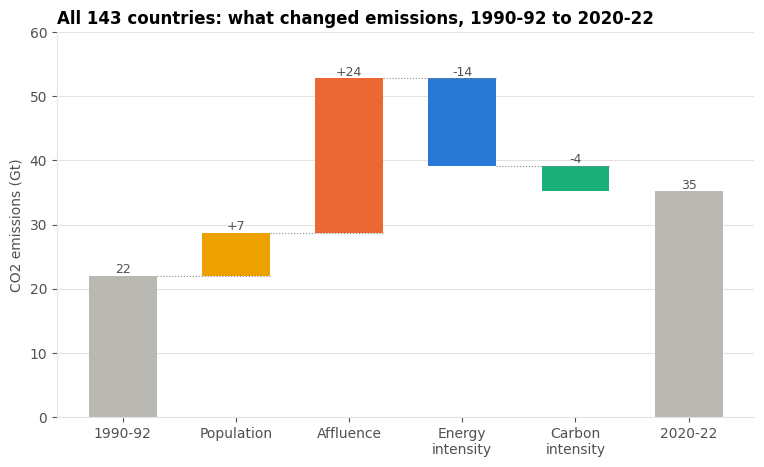

In [9]:
full_period = global_effects.iloc[0]
first, last = endpoints(sample, START_YEAR, END_YEAR)

fig, ax = plt.subplots(figsize=(9, 5))
waterfall(ax, first["co2"].sum() / 1000, full_period[FACTORS] / 1000, last["co2"].sum() / 1000,
          "All 143 countries: what changed emissions, 1990-92 to 2020-22", unit="Gt")
ax.set_ylim(0, 60)
fig.savefig(FIGURES / "04_global_waterfall.png")
plt.show()

In [10]:
# How much of the growth push was offset, in each period?
split = global_effects.iloc[1:]
push = split["Population"] + split["Affluence"]
pull = split["Energy intensity"] + split["Carbon intensity"]
pd.DataFrame({
    "growth push (Gt)": (push / 1000).round(1),
    "transition pull (Gt)": (pull / 1000).round(1),
    "share offset": (-pull / push * 100).round(0).astype(int).astype(str) + "%",
    "carbon intensity share of the pull": (split["Carbon intensity"] / pull * 100).round(0).astype(int).astype(str) + "%",
})

,growth push (Gt),transition pull (Gt),share offset,carbon intensity share of the pull
1990-2005,11.8,-6.4,54%,20%
2005-2022,17.2,-11.2,65%,22%


Across all 143 countries, growth in population and incomes added around 31 Gt of emissions between the start and end of the period. Efficiency and cleaner energy together removed about 18 Gt, leaving a net increase of roughly 13 Gt.

Comparing the two halves:
- The transition is **offsetting more of the growth** than before: roughly 54% of the growth push in 1990 to 2005, rising to about 65% in 2005 to 2022.
- **Cleaner energy is slowly gaining ground**: carbon intensity supplied 20% of the reduction in the first period and 22% in the second. Small, but moving the right way.

The direction of travel is right, but the world is still adding emissions faster than it removes them.

## A note on the method's limits

- **Energy intensity mixes two things.** A fall can come from genuine efficiency (better engines, insulation) or from the economy shifting away from heavy industry. The decomposition can't separate them. If heavy industry moved abroad, a country's energy intensity falls while the emissions just happen somewhere else. Notebook 05 tests this with consumption-based emissions.
- **How renewables are counted matters.** OWID's primary energy figures count wind, solar and hydro using the "substitution method" (as if they replaced fossil fuel power stations). That's good for this analysis: switching coal to wind shows up as cleaner energy, rather than making the economy look artificially efficient.
- **CO2 here includes cement and flaring**, not just burning fuel for energy. So carbon intensity is slightly broader than "how clean is the energy", though fuel combustion is the large majority of emissions for most countries.
- **GDP is measured in purchasing-power terms (2011 international dollars).** A different GDP measure would shift the split between affluence and energy intensity a little, though not the overall picture.

## Save the results

In [11]:
out = effects.round(1).join(effects_pct.round(1).add_suffix(" (%)"))
out.to_csv(TABLES / "kaya_decomposition.csv")
global_effects.round(0).to_csv(TABLES / "kaya_global_by_period.csv")
print(f"Saved decomposition for {len(out)} countries, plus the global summary by period")

Saved decomposition for 143 countries, plus the global summary by period


## Summary

- The decomposition is exact: the four effects add up to the real change in every country.
- **Efficiency did most of the work.** Falling energy intensity was the biggest brake on emissions in nearly every country, and the main lever in 30 of 34 absolute decouplers.
- **Rich countries also cleaned up their energy.** The UK, Germany, Denmark and Sweden cut carbon intensity by a fifth or more; Denmark by 42%.
- **Growth dominated elsewhere.** China's and India's rising incomes far outweighed their large efficiency gains, and India's energy became more carbon-intensive.
- **Globally, the transition is catching up but not there yet.** It offset about 54% of growth-driven emissions in 1990 to 2005, and about 65% in 2005 to 2022.

**Next:** notebook 05 tests the biggest open question here. Did rich countries' efficiency gains partly come from moving heavy industry overseas?